# Assignment 7

 1. "Action Recognition" on the KTH-Actions dataset (same as from Assignment 3)
    
    - Use same settings as in that assignment
    - Already downloaded in `/home/nfs/inf6/data/datasets/kth_actions`
    - Use spatial dimensionality of frames of 64x64
    - Split videos into subsequences of e.g. 10 frames. Treat each of these subsequences as independent.
    - Feel free to use augmentations (temporal and/or spatial)

<br>

 2. Train a transformer for 'Action Recongition'
     - Break each image into patches. You can decide on the pathc size
     - Jointly process all patches from the sequence with your transformer
     - Output a class prediction

<br>

 3. Evaluate your Transformer module:
     - Compare at least 2 different patch sizes
     - Compare with the performance of your RNN models from Assignment 3 (no need to retrain them)
    

<br>


 - **Extra Point**:
     - Train a transformer with Video-Vision-Transformer (ViViT) with Space-Time attention (https://arxiv.org/abs/2103.15691)
     - Compare your ViViT with the ViT from the main assignment

In [7]:
from utils import *
import shutil
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformations import *
from dataloader import KTHActionDataset
import models
import utils
from torch.utils.tensorboard import SummaryWriter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [66]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:

categories = ['walking', 'jogging', 'running', 'boxing', 'handwaving', 'handclapping']

# Create datasets
root_dir = "/home/nfs/inf6/data/datasets/kth_actions/processed/"

train_dataset = KTHActionDataset(root_dir, 
                                 split="train", 
                                 transform=get_train_transforms(8), 
                                 max_frames=80, 
                                 img_size=(64, 64))

test_dataset = KTHActionDataset(root_dir, 
                                split="test", 
                                transform=get_test_transforms(8), 
                                max_frames=80, 
                                img_size=(64, 64))


### Regading Dataloader:

We realized that there is a great disparency in the dataset. There are frequent large amount of empty frames (say 100) with no objects/actions inside. This was greatly contributing to low network performance. Therefor, we choose 80 frames (with random index inside a folder, while preserving the sequence order) each time we choose a training data folder and then in the transformations we slice the data by 8, so that we get 10 frames during training that are (hopefully!) more meaningful and indicate some actions being performed by the person. 

### Data visualization

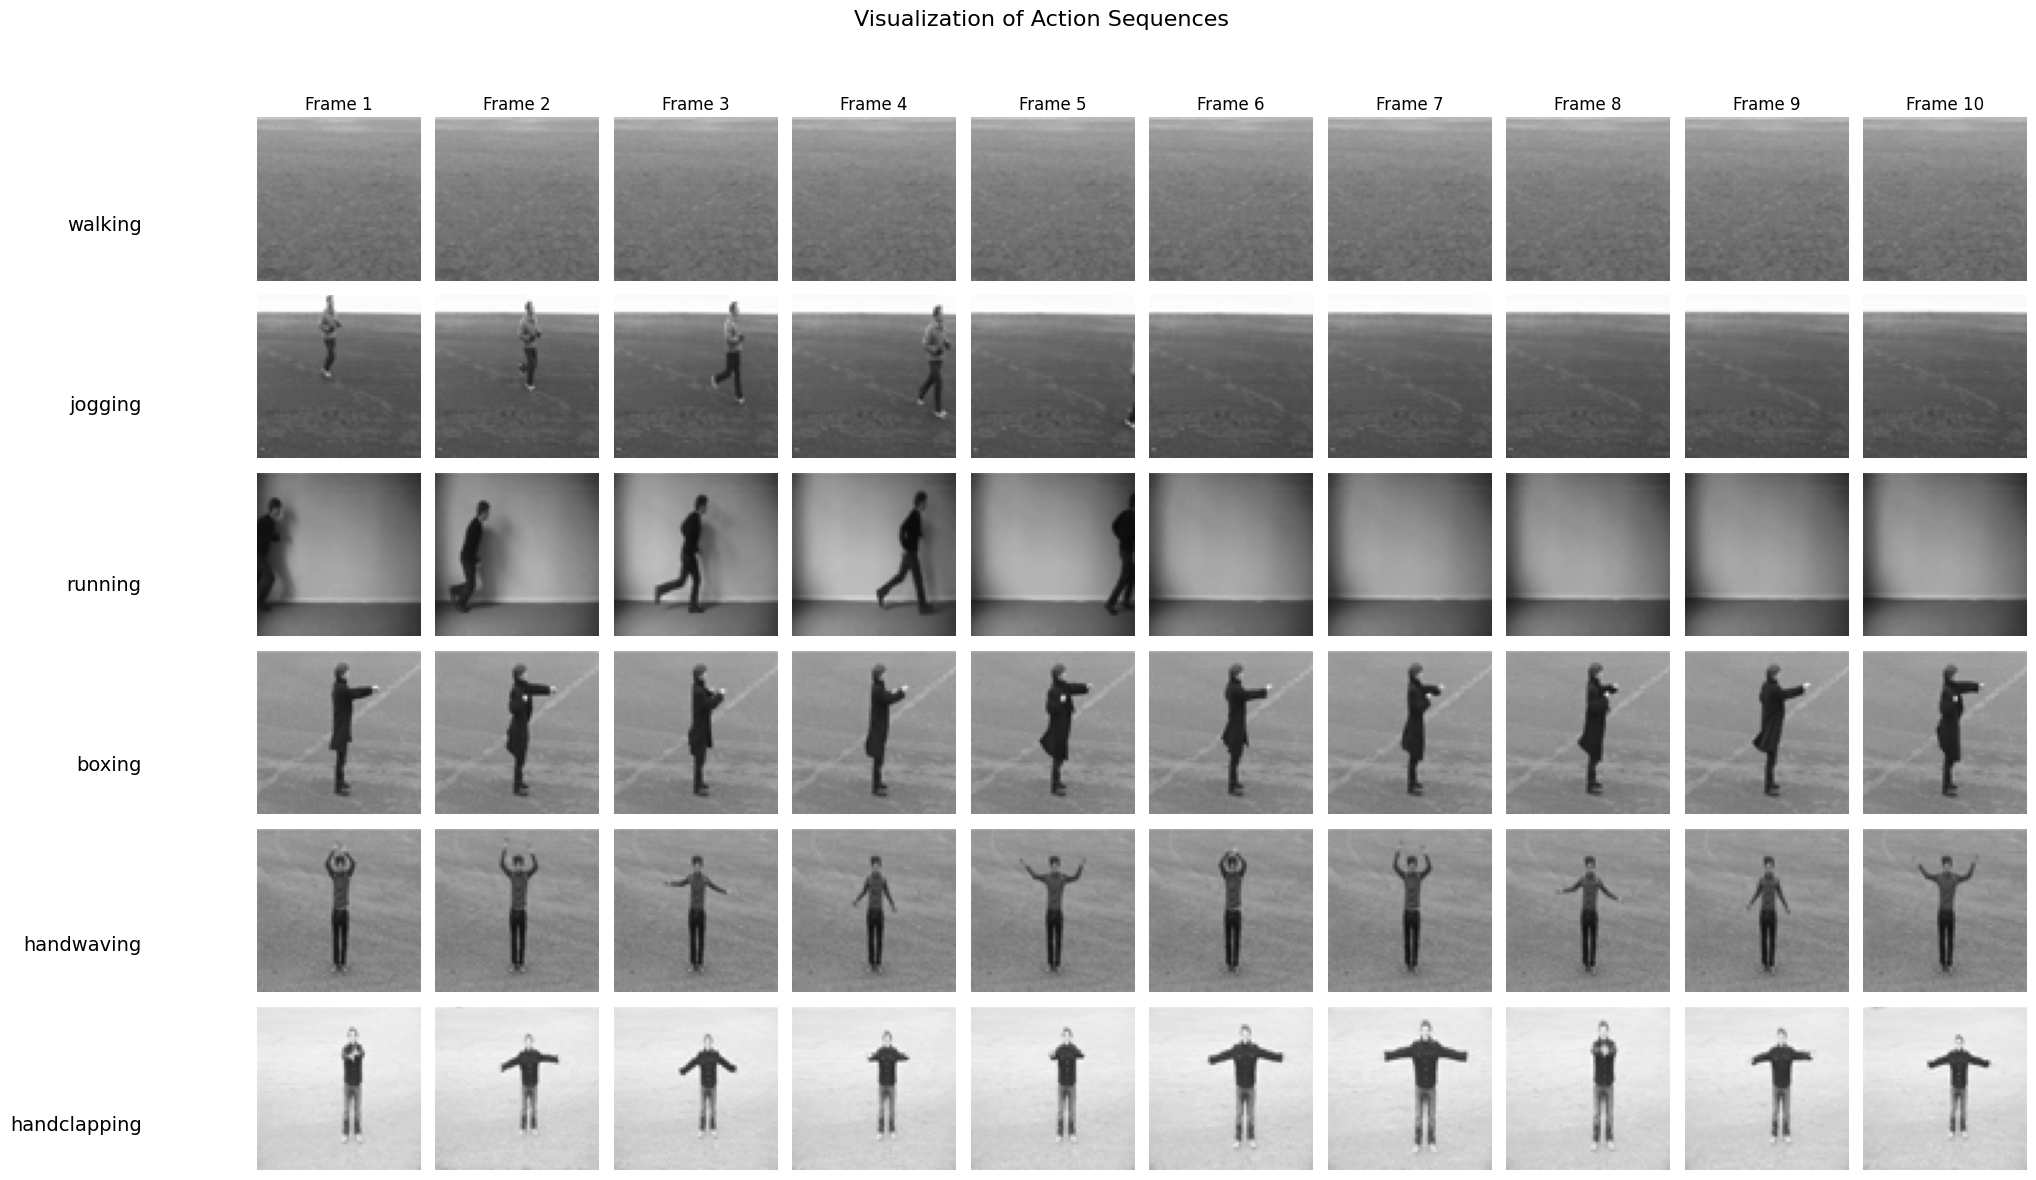

In [89]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=4)

frames, labels = next(iter(test_loader))

unique_labels = np.unique(labels.numpy())
fig, axes = plt.subplots(len(unique_labels), 10, figsize=(20, 12))
fig.suptitle('Visualization of Action Sequences', fontsize=16)

if len(unique_labels) == 1:
    axes = np.expand_dims(axes, axis=0)

categories = ['walking', 'jogging', 'running', 'boxing', 'handwaving', 'handclapping']

# For each action category in this batch
for i, action_idx in enumerate(unique_labels):
    # Find all samples of this action in the batch
    action_samples = frames[labels == action_idx]
    if len(action_samples) > 0:
        sample = action_samples[0]
        
        for frame_idx in range(10):
            frame = sample[frame_idx].squeeze().cpu().numpy()
   
            axes[i, frame_idx].imshow(frame, cmap='gray', vmin=0, vmax=1)
            axes[i, frame_idx].axis('off')
            
            # Add frame number to the first row
            if i == 0:
                axes[i, frame_idx].set_title(f'Frame {frame_idx+1}')
    
    row_height = 0.9/len(unique_labels)
    row_center = 0.9 - (i * row_height + row_height/2)
    action_name = categories[action_idx.item()]
    
    # Move label down by adding a negative offset to y-coordinate
    vertical_offset = 0.025  # Approximate adjustment for 0.3cm
    fig.text(0.05, row_center - vertical_offset, 
             action_name, 
             fontsize=14, 
             ha='right',
             va='center')

plt.tight_layout(rect=[0.1, 0, 1, 0.95]) 
plt.show()

In [12]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, 
                          batch_size=32, 
                          shuffle=True, 
                          num_workers=4)

test_loader = DataLoader(test_dataset, 
                         batch_size=32, 
                         shuffle=False, 
                         num_workers=4)

In [13]:
## Verifying the dataloader  
for batch in test_loader:
    frames, labels = batch
    print(f"Batch shape: {frames.shape}, Labels: {labels.shape}")
    break

Batch shape: torch.Size([32, 10, 1, 64, 64]), Labels: torch.Size([32])


In [14]:
from models import TransformerBlock

tf_block = TransformerBlock(
        token_dim=128,
        attn_dim=128,
        num_heads=4,
        mlp_size=512
    ).to(device)

tf_block

TransformerBlock(
  (ln_att): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
  (attn): MultiHeadSelfAttention(
    (q): Linear(in_features=128, out_features=128, bias=False)
    (k): Linear(in_features=128, out_features=128, bias=False)
    (v): Linear(in_features=128, out_features=128, bias=False)
    (out_proj): Linear(in_features=128, out_features=128, bias=False)
  )
  (ln_mlp): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
  (mlp): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=128, out_features=512, bias=True)
      (1): GELU(approximate='none')
      (2): Linear(in_features=512, out_features=128, bias=True)
    )
  )
)

### Experiments with different patch sizes

**With Patch size = 16 we will have:**

In [ ]:
from models import Patchifier

patch_size = 16

patchifier = Patchifier(patch_size=patch_size)

img, _ = next(iter(test_loader))
print(f"Input Shape: {img.shape}")
patch_data = patchifier(img)
print(f"Patchified Shape: {patch_data.shape}") # (B, seq_len, num_patch_H * num_patch_W, 1 * 16 * 16)


Input Shape: torch.Size([32, 10, 1, 64, 64])
Patchified Shape: torch.Size([32, 10, 16, 256])


Image Shape: torch.Size([1, 64, 64])
Number of patches: 16
Patch size: 16


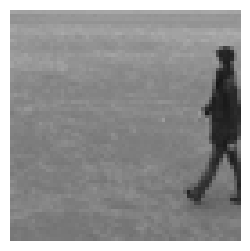

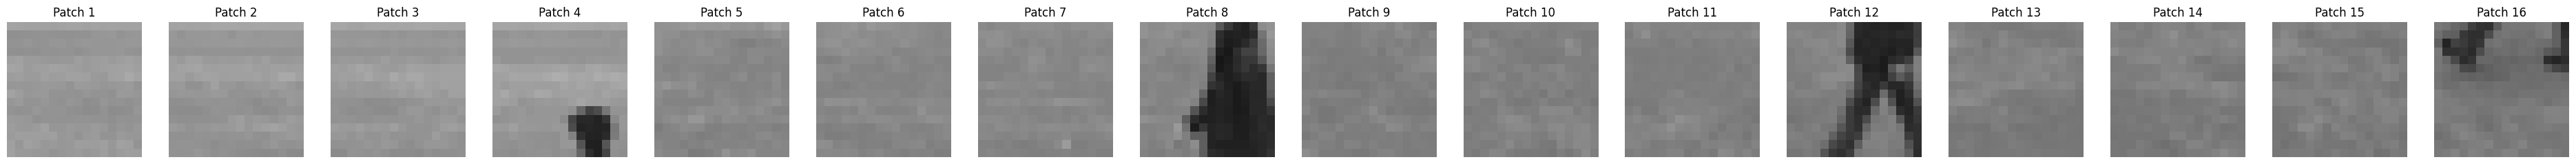

In [87]:
BATCH_IDX = 4
seq_len = 5
plt.figure(figsize=(3, 3))
plt.imshow(img[BATCH_IDX, seq_len].permute(1, 2, 0), cmap='gray', vmin=0, vmax=1)
print(f"Image Shape: {img[BATCH_IDX, seq_len].shape}")
plt.axis("off")

num_patches = patch_data.shape[2] # num_patches = num_patch_H * num_patch_W
print(f"Number of patches: {num_patches}")
patch_size = patchifier.patch_size # patch_size = 16, this the the H,W of each single patch
print(f"Patch size: {patch_size}")
fig, ax = plt.subplots(1, num_patches)
fig.set_size_inches(3 * num_patches, 3)
for i in range(num_patches):
    cur_patch = patch_data[BATCH_IDX, seq_len, i].reshape(1, patch_size, patch_size)
    ax[i].imshow(cur_patch.permute(1, 2, 0), cmap='gray', vmin=0, vmax=1)
    ax[i].set_title(f"Patch {i+1}")
    ax[i].axis("off")

plt.show()

### Positional Encoding

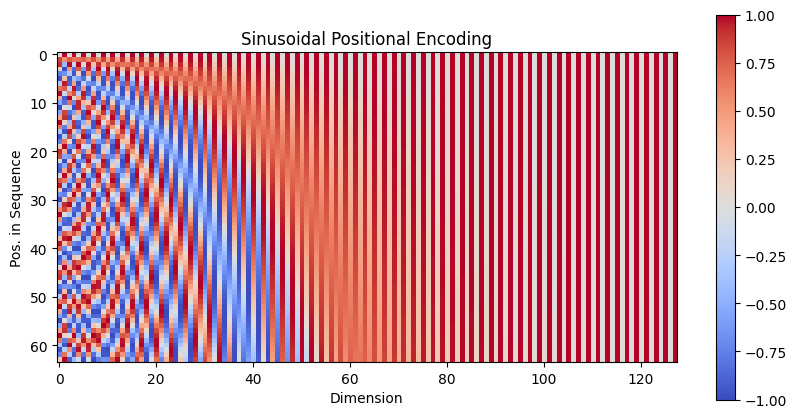

In [88]:

pe = models.PositionalEncoding(d_model=128, max_len=64)

plt.figure(figsize=(10, 5))
plt.imshow(pe.pe[0], vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar()
plt.title("Sinusoidal Positional Encoding")
plt.xlabel("Dimension")
plt.ylabel("Pos. in Sequence")
plt.show()

## Evaluations

* with path_size = 32:


In [49]:
from models import ViT
patch_size = 32
vit = ViT(
        patch_size=patch_size,
        token_dim=128,
        attn_dim=128,
        num_heads=4,
        mlp_size=512,
        num_tf_layers=4,
        num_classes=len(categories),
        C=1,
        max_len=64
    ).to(device)

# vit

In [54]:
with torch.no_grad():
    y = vit(img.to(device))
attn_maps = vit.get_attn_mask()


In [32]:
optimizer = torch.optim.Adam(vit.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss()

vit, optimizer, epoch, stats = utils.load_model(vit, optimizer, savepath="checkpoints/checkpoint_ViT_patch_size_32_epochs_60.pth")

loss_iters = stats['loss_iters']
val_loss = stats['valid_loss']
train_loss = stats['train_loss']
valid_acc = stats['valid_acc']

# utils.visualize_progress(loss_iters, train_loss, val_loss, valid_acc, start=0)
# plt.show()

In [33]:
acc, loss = utils.eval_model(vit, test_loader, criterion, device)
print(f"Test Accuracy: {acc}")

Test Accuracy: 40.74074074074074


In [34]:
imgs, labels = next(iter(test_loader))
imgs = imgs.to(device)
with torch.no_grad():
    preds = vit(imgs)
cls_preds = preds.argmax(dim=-1).cpu()

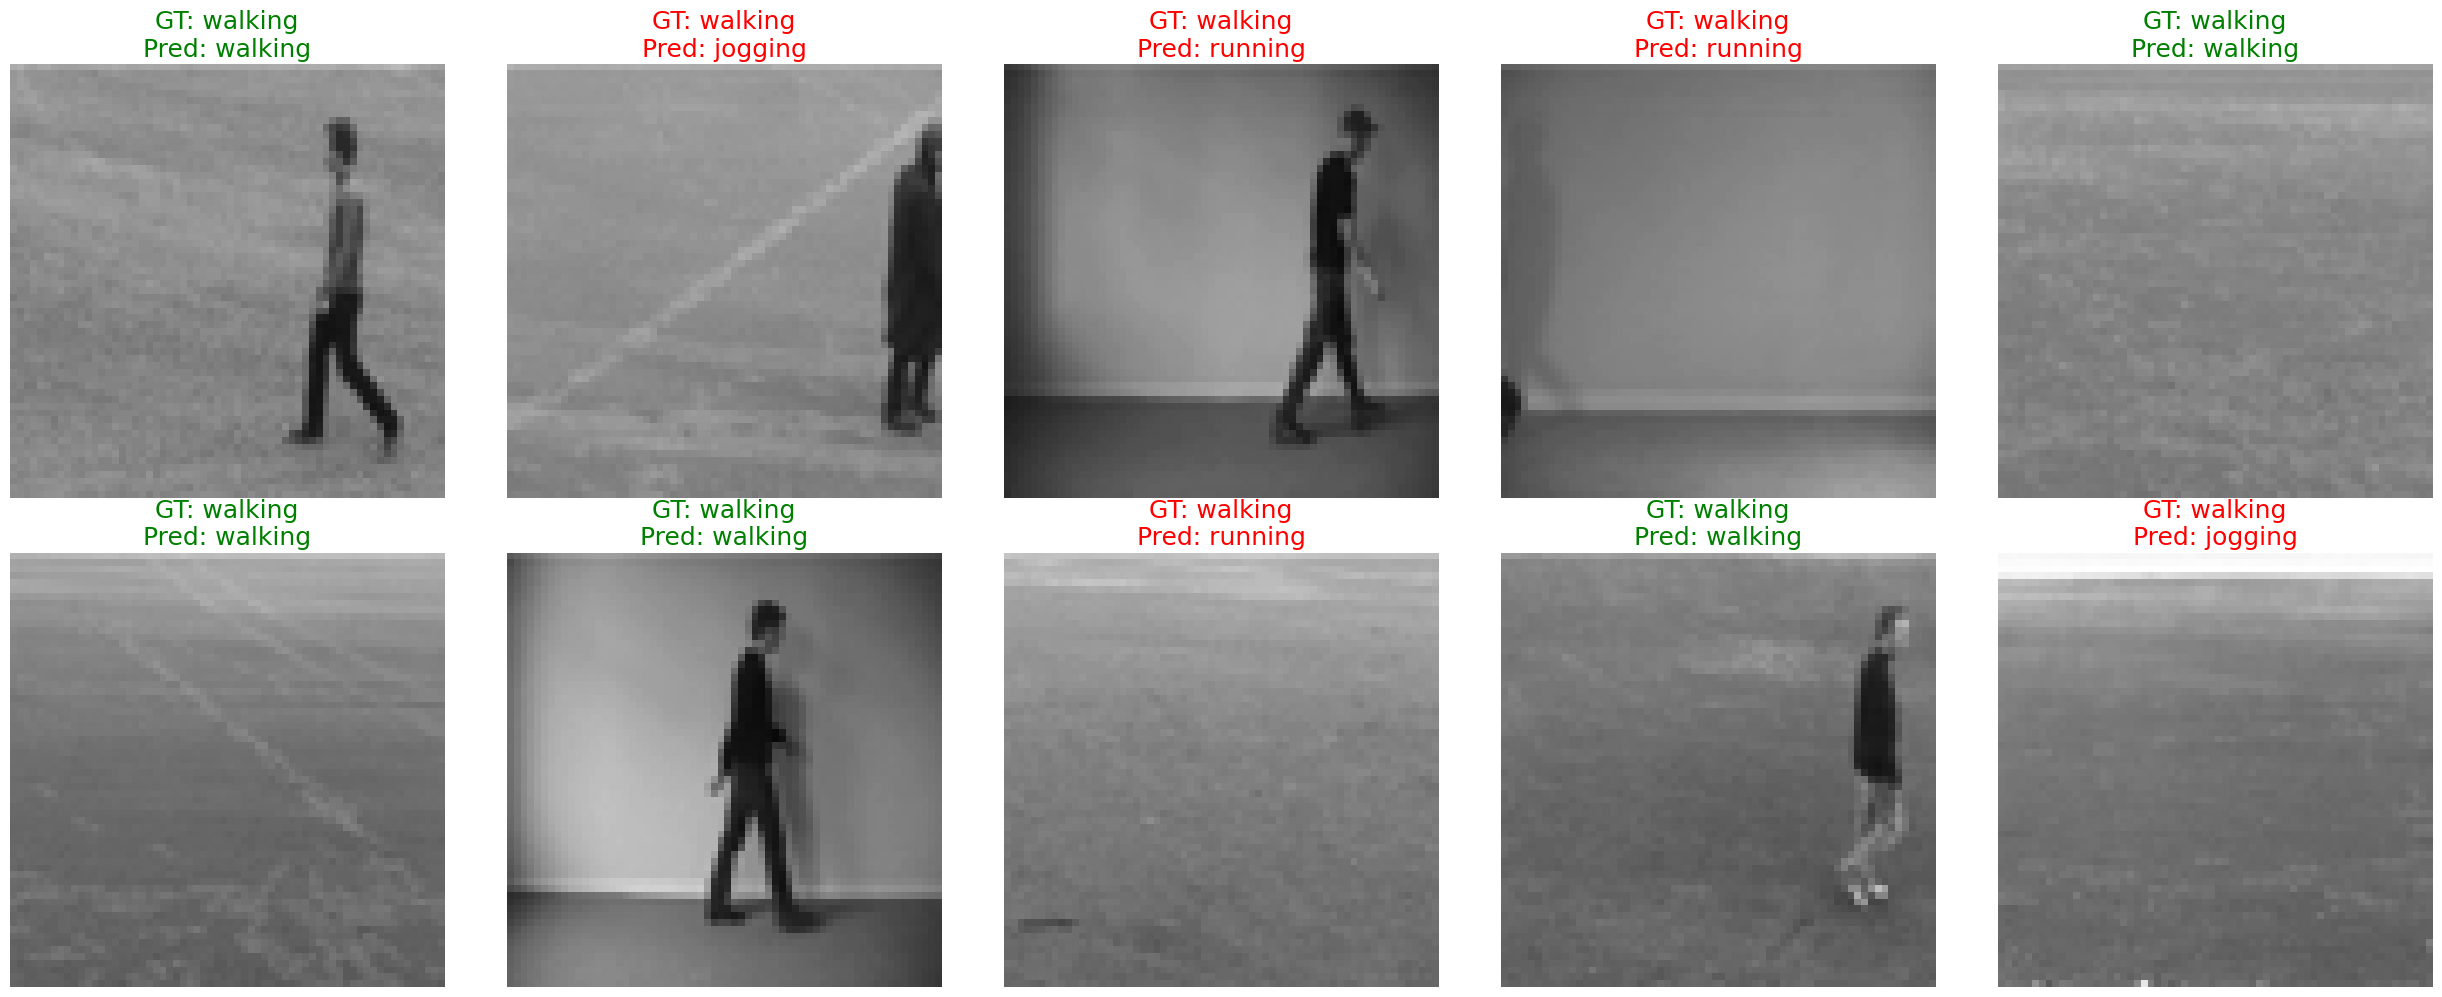

Correct predictions: 5/10 (50%)


In [77]:
fig, ax = plt.subplots(2, 5, figsize=(25, 10))

for i in range(10):
    row = i // 5  # Calculate row index
    col = i % 5   # Calculate column index
    
    img_to_show = imgs[i, 0].permute(1, 2, 0).detach().cpu() 
    
    ax[row, col].imshow(img_to_show, cmap='gray', vmin=0, vmax=1)
    gt_cls = categories[labels[i]]
    pred_cls = categories[cls_preds[i]]
    
    # Color code the title based on prediction correctness
    color = 'green' if gt_cls == pred_cls else 'red'
    
    ax[row, col].set_title(f"GT: {gt_cls}\nPred: {pred_cls}", fontsize=18, color=color)
    ax[row, col].axis("off")

plt.tight_layout()
plt.show()

# Print summary statistics
correct_predictions = sum(1 for i in range(10) if categories[labels[i]] == categories[cls_preds[i]])
print(f"Correct predictions: {correct_predictions}/10 ({correct_predictions*10}%)")


### Visualizing attention heads

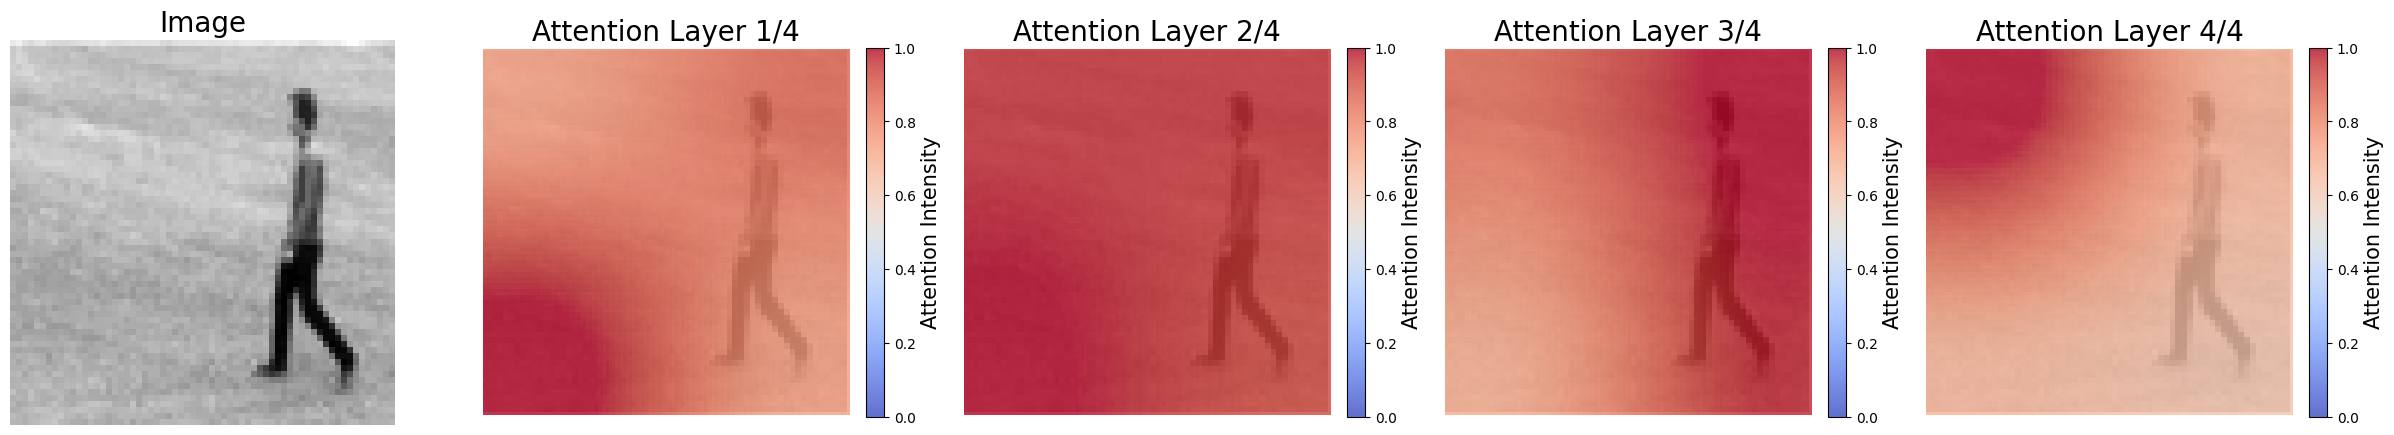

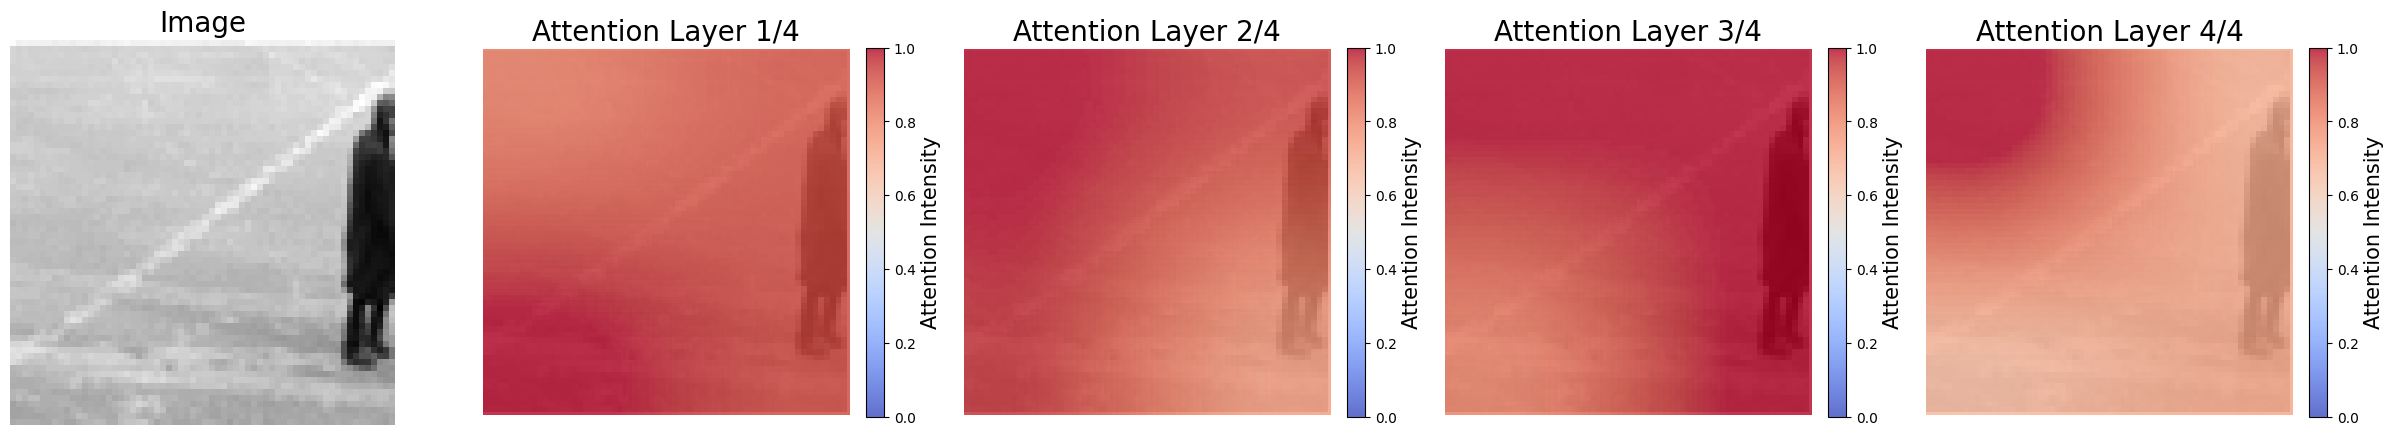

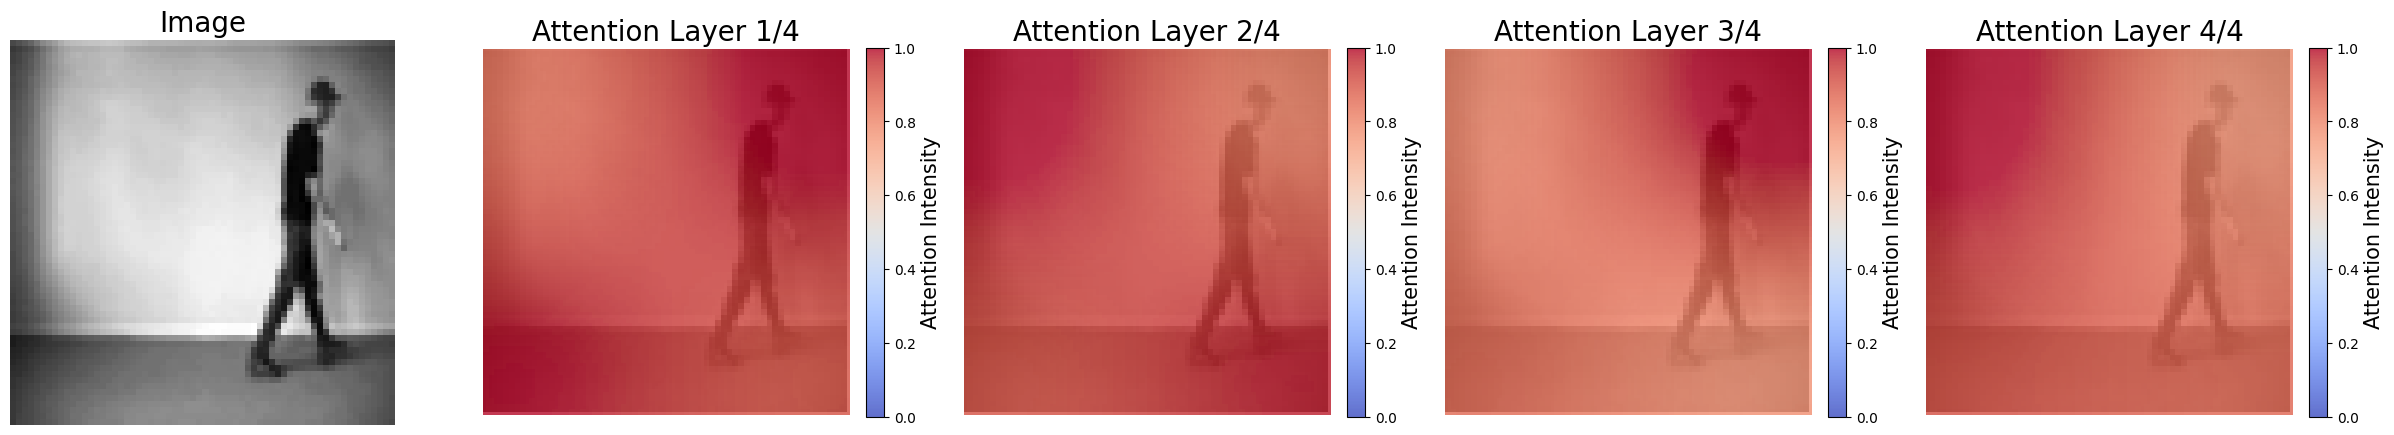

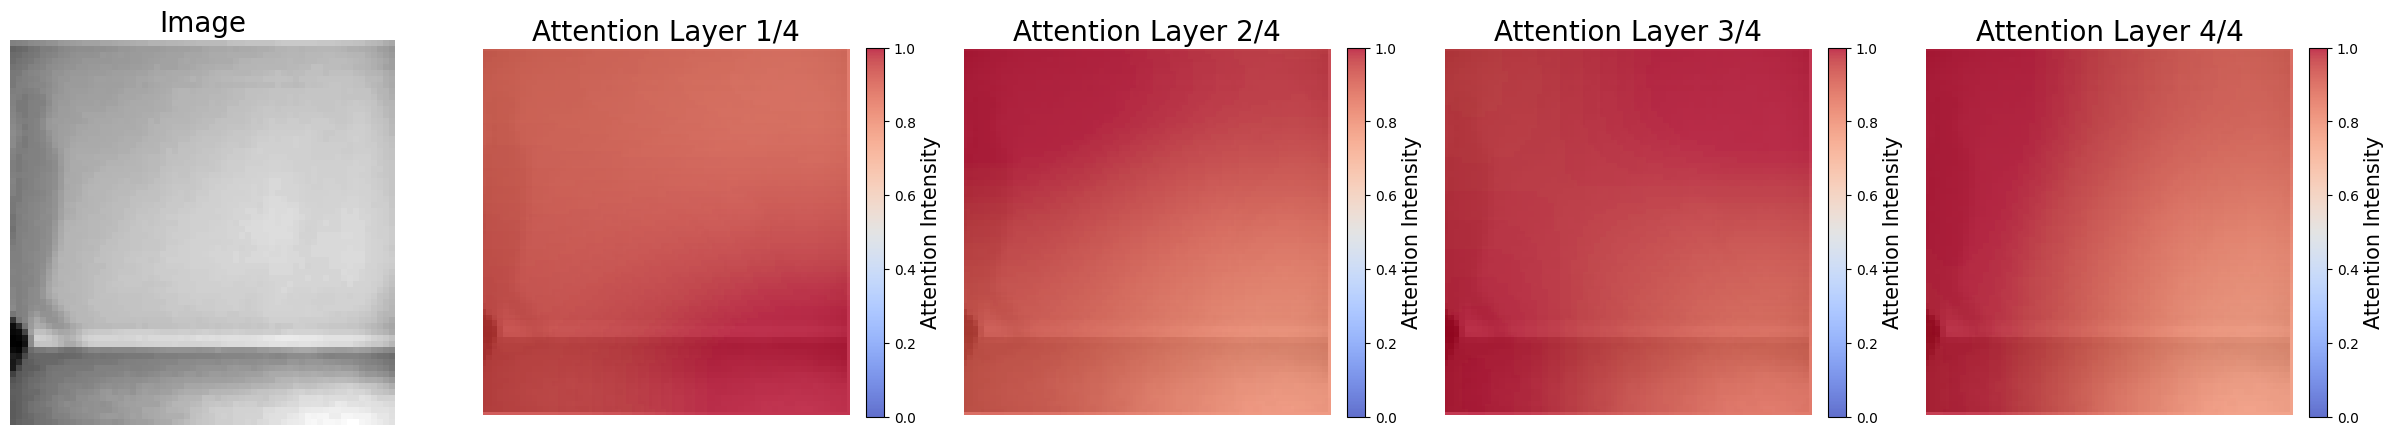

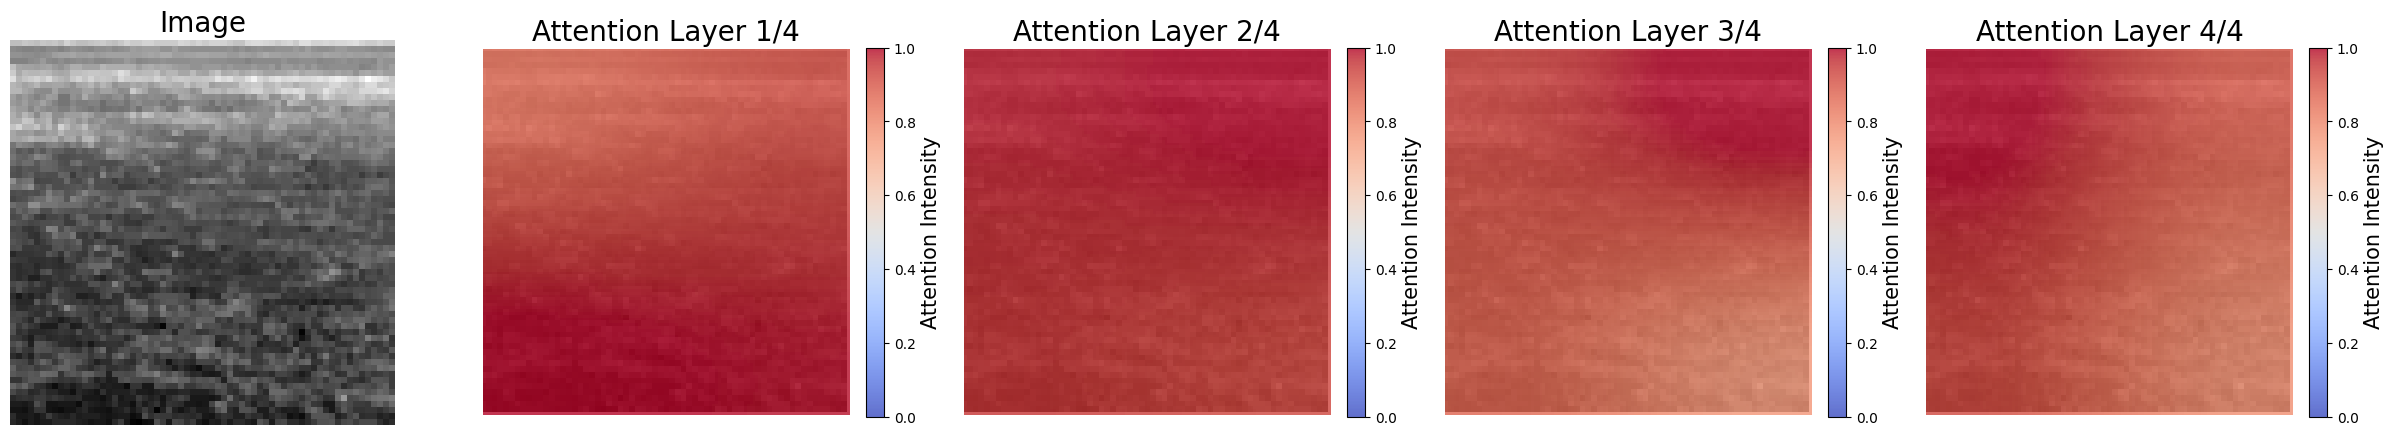

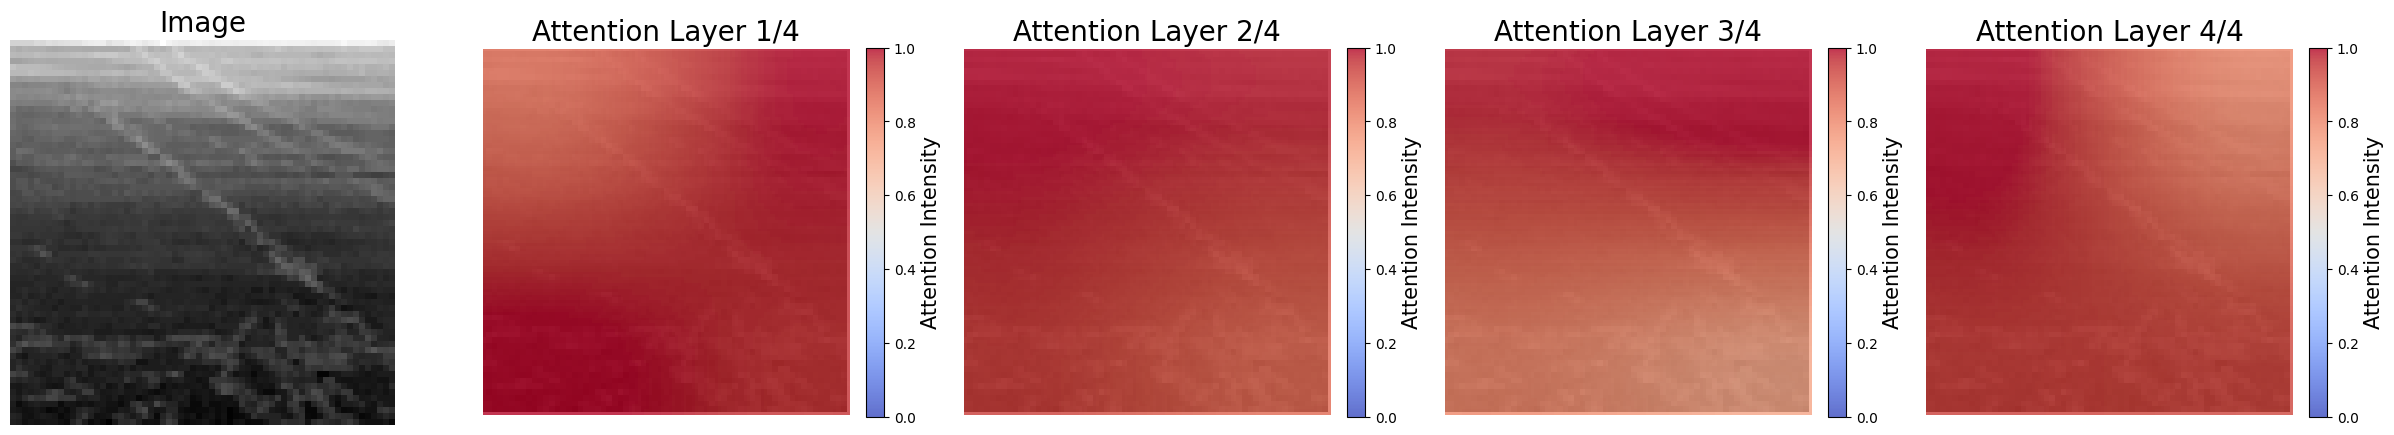

In [75]:
attn_maps = vit.get_attn_mask()

# keeping only the attention map for the [CLS] query
attn_maps = [attn_map[:, :, 0] for attn_map in attn_maps]

for BATCH_IDX in range(6):
    img_numpy = imgs[BATCH_IDX,0].cpu().permute(1, 2, 0).numpy()
    attns_numpy = [attn_map[BATCH_IDX].cpu().float().numpy() for attn_map in attn_maps]
    utils.visualize_attention(img_numpy, attns_numpy,patch_size=32)


**$Final\ remarks:$**

We found comparison between different experiments a bit tricky for this task! We ran diffenrent experiments with different path sized are the results were as following:

| Patch size | Max Accuracy achieved (%)|
|------------|-----------------------|
| 8          | 46.72    |
| 16         | 44.91    |
| 32         | 47.69    |
| 64         | 47.62    |

- On normal condition, choosing a smaller patch size (e.g., 8) should potentially lead to better spatial understanding and detailed feature perception if the inpiut image, resulting in highere accuracy. Wheras larger patch sizes (e.g 32-64) would result in more high-level comprehension. With patch size = 64, we are basically treating the whole input image as one token! Although this could help in some tasks (e.g., text summarization), in the scope of this project it should have been resulted in lower accuracy.

- Nevertheless, for the given dataset, as the amount of sparcity in data is large, and also because for each epoch we choose random sequence of images for each action, we are not sure which training experience and config has seen more meaningful data during the training!! Also, we will be getting many empty frames during training and therefor, the Vit model could not perform better than the mentioned results. Consequently, we believe the achieved results above might not be the most meaningful as they could be!

- Compared to the third assignment, wo got relatively the same results. For LSTMCELL and GRUCELL, we could achieve 47.99 and 49.1 percent of accuracy, respectively. Although using a pre-trained ConvLSTM in could improve the results up to 84% of accuracy!